# <span style = 'color:red'> This is out of date. Don't use it anymore other than for reference. <span>

Use MCMC & Zeus to extract parameter values \
Based off of the Zeus tutorial

In [18]:
import cosmo_calc
import importlib
import zeus21
import emcee
import eplots
Plotter = eplots.Plotting()
from scipy.stats import mode
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Math
import estats

In [2]:
# Get cosmological parameters, class to construct the HMF from Zeus
CosmoParams_input = zeus21.Cosmo_Parameters_Input(zmin_CLASS=0.0)
CosmoParams,ClassyCosmo, CorrFclass ,HMFintclass =  zeus21.cosmo_wrapper(CosmoParams_input)

In [3]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/research/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

# Functions

In [67]:
def time_evolution(paramvector, z, scale):
    log10epsstar_base, dedz, log10Mcstar_base, dMdz, alphastar_base, dadz, betastar_base, dbdz, sigmaUV_base, dsdz = paramvector
    
    # Divide by scale so that the d/dz parameters can scale similarly to other parameters
    log10epsstar = log10epsstar_base + (dedz*z/scale)
    log10Mcstar = log10Mcstar_base + (dMdz*z/scale)
    alphastar = alphastar_base + (dadz*z/scale)
    betastar = betastar_base + (dbdz*z/scale)
    sigmaUV = sigmaUV_base + (dsdz*z/scale)
    
    return [log10epsstar, log10Mcstar, alphastar, betastar, sigmaUV]

In [5]:
def param_wrapper(paramvector, CosmoParams, z, scale):
    """
    Puts paramvector into a format that Zeus can read
    paramvector [1darray]: log10eps, log10Mc, alpha, beta
    """
    log10epsstar, log10Mcstar, alphastar, betastar, sigmaUV = time_evolution(paramvector, z, scale)
    astroparams = zeus21.Astro_Parameters(CosmoParams,epsstar=10**log10epsstar, Mc=10**log10Mcstar,alphastar=alphastar, betastar=betastar,
                                         sigmaUV = sigmaUV) 
    
    return astroparams

In [6]:
def UVLF_wrapper(zcenters, zwidths, MUVcenters, MUVwidths, paramvector, CosmoParams, scale):
    'Computes and returns the UVLF at z=zcenters, with width zwidths, in bins centered at MUVcenters with width MUVwidths'
    'Output is PhiUV, depends on astro parameter inputs paramvector'
    astroparams = param_wrapper(paramvector, CosmoParams, zcenters, scale)
    UVLFs_std = zeus21.UVLFs.UVLF_binned(astroparams,CosmoParams,HMFintclass,zcenters,zwidths,MUVcenters,MUVwidths)
    return UVLFs_std

In [7]:
def log_prior(paramvector, lowers, uppers):
    if all(lower < t < upper for t, lower, upper in zip(paramvector, lowers, uppers)):
        return 0.0  # log(1)
    # else: # Debugging
    #     for t,lower,upper in zip(paramvector, lowers, uppers):
    #         if lower<t<upper:
    #             continue
    #         else:
    #             print(t)
    return -np.inf  # log(0)

    
def log_like(paramvector, datavector, CosmoParams, scale, MINRELERROR = 0.2):
    'Sample flat in eps, alpha, beta, log10Mc, and sigmaUV. Datavector has all the z and UVLF data'
    
    #now bin it appropriately at each z -- data part
    loglike_curr = 0.0

    for dataarrayz in datavector: # Add the log likelihoods together for each redshift. The log likelihood is just a sum over all the points
        # anyways, so this makes sense
        #datHSTz4=[3.8, mags_z4,phi_z4,err_z4,errx_z4]
        zdat = dataarrayz[0]
        zerr = dataarrayz[1]
        xdat = dataarrayz[2]
        ydat = dataarrayz[3]
        yerr = dataarrayz[4] 
        xerr = dataarrayz[5]                
        #izus = np.argmin(np.abs(z0list - zdat))      
        
        yerr = np.fmax(yerr, ydat*MINRELERROR) # Make sure error bars aren't any smaller than the relative error set above

        uvlftheory = UVLF_wrapper(zdat,zerr,xdat,xerr, paramvector, CosmoParams, scale)
        
        loglike_curr += -np.sum( (ydat - uvlftheory)**2/(2.0 * yerr**2) ) #assumed Gaussian, to be revisited.
    
    return loglike_curr


def log_prob(paramvector, datavector, CosmoParams, lowers, uppers, scale):   
    lprior=log_prior(paramvector, lowers, uppers)
    if (lprior > -np.inf): #only run if in prior range. avoid weird behavior for negative logs etc
        lpost=log_like(paramvector, datavector, CosmoParams, scale)
    else:
        lpost = 0.0 #doesn't matter, added to -inf
    #print(paramvector)
    return lprior + lpost

In [8]:
def generate_ICs(params1, lowers, uppers, nwalkers, scale = 100):
    ndim = len(params1)
    step_size = [(upper-lower)/scale for upper, lower in zip(uppers, lowers)]
    p0 = params1 + step_size * (np.random.randn(nwalkers, ndim))

    return p0

# Run MCMC

In [9]:
# Set up
labels = [r"$\log(\epsilon_0)$", r'$d\log(\epsilon_0)/dz$', r'$\log(M_c)$', r'$d\log(M_c)/dz$', r"$\alpha$", r"$d\alpha/dz$", r"$\beta$", 
          r"$d\beta/dz$", r'$\sigma_{\rm{UV}}$', r'$d\sigma_{\rm{UV}}/dz$']
scale = 100 # This is what to scale your d/dz parameters by so that the steps are reasonable
params1 = np.array([-1, .01*scale, 12, .01*scale, 0.6, .01*scale, -0.5, .01*scale, 0.5, .01*scale])
lowers = [-5, -.5*scale, 10, -.5*scale, 0, -.5*scale, -3, -50, 0, -.5*scale]
uppers = [1, .5*scale, 15, .5*scale, 3, .5*scale, 0, 50, 2, .5*scale]
ndim = len(params1)
nwalkers = 2*ndim
p0 = generate_ICs(params1, lowers, uppers, nwalkers)

In [10]:
# Run a short MCMC to spread ICs out a bit
sampler_hst = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[datHST, CosmoParams, lowers, uppers, scale]) 
state_hst = sampler_hst.run_mcmc(p0, 100)

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


In [11]:
# Run the real MCMC
Nsteps=2000
sampler_hst.run_mcmc(state_hst, Nsteps) # Use the result of the last MCMC as starting values

State([[-6.70925997e-01 -4.88323204e+00  1.12222668e+01  1.22718417e+00
   1.18856759e+00 -4.18574074e+00 -1.44628013e+00  2.29474024e+01
   1.28303712e+00 -1.09200732e+01]
 [-7.08436992e-01 -3.03850584e+00  1.13001828e+01  1.04320776e+01
   7.48721825e-01 -1.03924156e+00 -2.01738463e+00 -1.02579464e+01
   1.09990841e+00 -5.71174440e+00]
 [-3.82154074e-01 -1.62765384e+01  1.18293880e+01 -6.01363514e+00
   6.78214072e-01 -8.48220086e-01 -2.93482668e+00 -5.28307367e+00
   1.13659408e+00 -9.66788236e-01]
 [ 3.33320522e-01 -2.89057292e+01  1.24217580e+01 -1.51583120e+01
   6.79546264e-01 -2.08220275e+00 -1.40097890e+00  3.81264868e+00
   2.54655623e-01  1.33216050e+01]
 [-1.07566567e+00  1.78163842e+00  1.09214596e+01  1.40122577e+01
   8.61089552e-01 -2.80998036e+00 -1.68089949e+00  3.67019098e+00
   1.63960430e+00 -1.45682168e+01]
 [-4.38510017e-01 -9.87795901e+00  1.21676237e+01 -7.02182507e+00
   3.65072873e-01  5.46394365e+00 -4.45937433e-01 -4.59414913e+01
   8.80152348e-01 -1.567865

In [12]:
samples_hst = sampler_hst.get_chain(discard = 400, flat=True)

# Plots

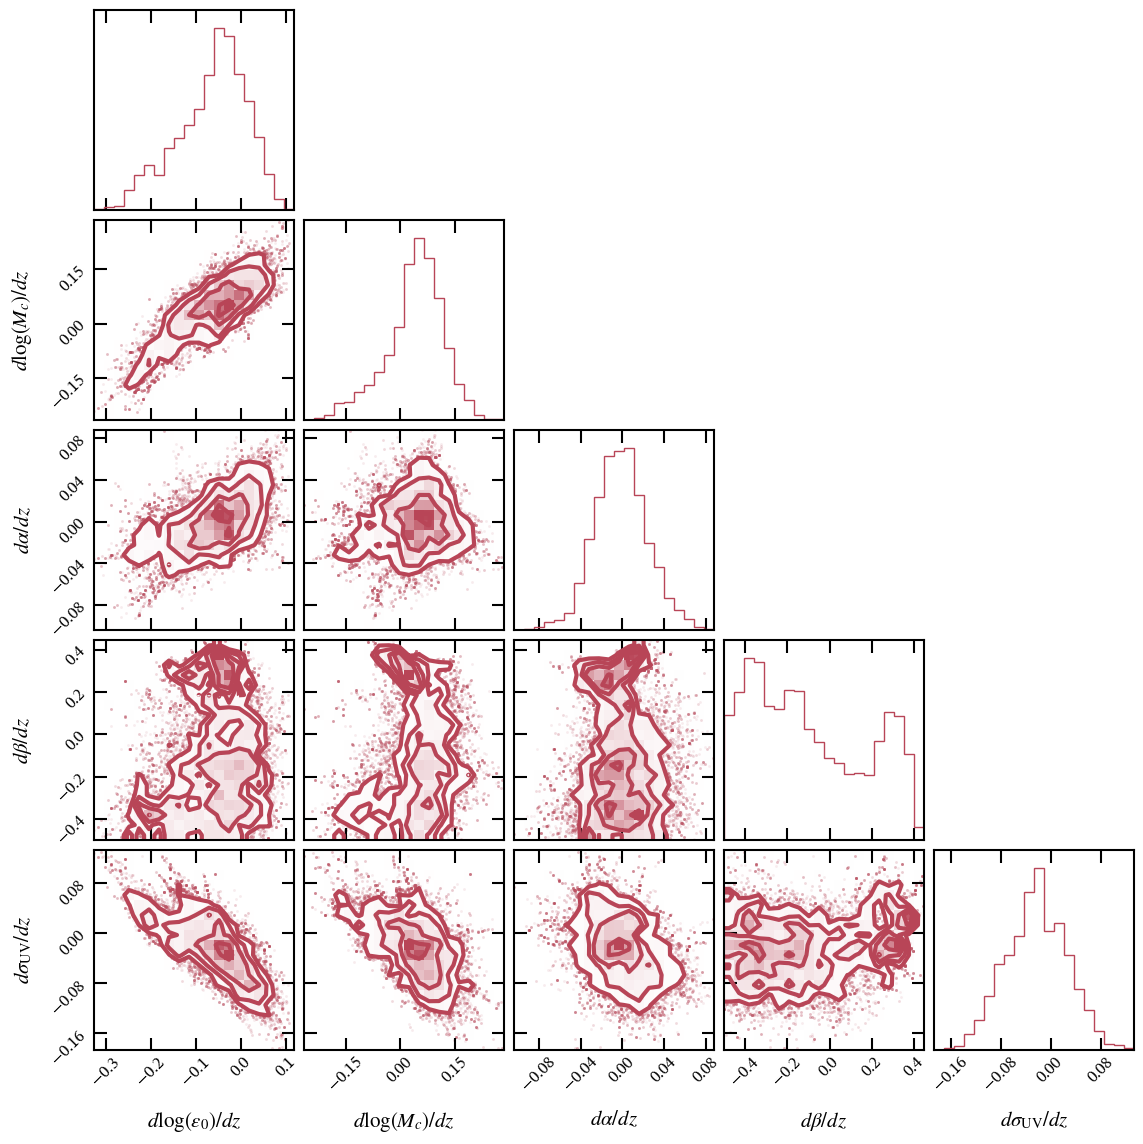

In [13]:
corner_plot = Plotter.plot_corner(samples_hst[:,1::2]/scale, labels[1::2]) # [1::2] means start at index 1 & step by 2s-- so, odd numbers

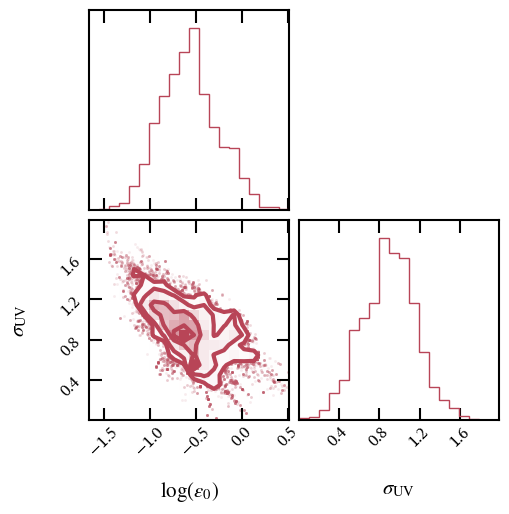

In [46]:
corner_plot = Plotter.plot_corner(samples_hst[:,[0,8]], [labels[0], labels[8]])
#corner_plot.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/corner_sig_eps.png', bbox_inches='tight')

In [19]:
def MCMC_vs_data(data, all_samples, CosmoParams, scale, bf_type = 'average', data_label = 'Bouwens+21', Plotting = None, nsamples = 100, 
                 truths = None):
    """
    my_MCMC [UVLF_MCMC object]
    """
    assert bf_type in ['average', 'mode'], 'The best fit type must be either average or mode'
    
    if Plotting is None:
        Plotting = eplots.Plotting()
    
    fig, ax = plt.subplots()
    inds = np.random.randint(len(all_samples), size=nsamples) # Choose nsamples from the chain

    # Decompose the data
    zdat = data[0]
    zerr = data[1]
    xdat = data[2]
    ydat = data[3]
    yerr = data[4] 
    xerr = data[5]      
        
    for ind in inds:
        sample = all_samples[ind]
        ax.plot(xdat, np.log10(UVLF_wrapper(zdat,zerr,xdat,xerr, sample, CosmoParams, scale)), alpha=nsamples/3000, color = Plotting.red, 
                zorder = 0)

    if truths is not None: # Plot the true curve if one is known. Otherwise, plot the best fit
        grid = np.linspace(np.min(xdat), np.max(xdat), 100) # Make a continuous grid if there is a true model available
        ax.plot(grid, np.log10(UVLF_wrapper(zdat,zerr,xdat,xerr, truths, CosmoParams, scale)), color = Plotting.red, label = 'true UVLF', 
                zorder = 1)
    else: 
        if bf_type == 'mode':
            best_fit = mode(all_samples, axis = 0).mode # Mode seems to be a better statistics than average
        else:
            best_fit = np.average(all_samples, axis = 0)
        ax.plot(xdat, np.log10(UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit, CosmoParams, scale)), color = Plotting.red, 
                label = f'best fit ({bf_type})', zorder = 1)
    
    ax.plot([0], [0], color = Plotting.red, alpha = 0.5, label = 'sampled fits') # Create the label for the samples
    ax.errorbar(xdat, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, color = Plotting.navy, 
                label = data_label)
    
    ax.invert_xaxis()
    ax.legend()
    ax.set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+1)
    ax.set_xlim(np.max(xdat)+0.25, np.min(xdat)-0.25)
    
    ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
    ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
    ax.set_title(f'UVLF data vs. MCMC model, $z \simeq {int(zdat)}$')

    return fig, best_fit

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_85065/764812332.py:50: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'UVLF data vs. MCMC model, $z \simeq {int(zdat)}$')


In [64]:
def MCMC_vs_data_varyz(data, all_samples, CosmoParams, scale, bf_type = 'average', data_label = 'Bouwens+21', Plotting = None, 
                       nsamples = 100, truths = None, title = 'UVLF data vs. MCMC fit', MINRELERROR = 0.2):
    """
    all_samples [ndarray]: Results from MCMC
    """
    # Figure out how many subplots to make
    zs = [dat[0] for dat in data]
    nz = len(zs)
    fig, ax = plt.subplots(1, nz, sharey = True)
    fig.set_size_inches(3.5*nz, 3)
    plt.subplots_adjust(wspace = 0.1)

    if Plotting is None:
        Plotting = eplots.Plotting()

    assert bf_type in ['average', 'mode'], 'The best fit type must be either average or mode'

    for i, (dat, z) in enumerate(zip(data, zs)):

        # Choose random samples from the MCMC chain
        inds = np.random.randint(len(all_samples), size=nsamples) # Choose nsamples from the chain
    
        # Decompose the data
        zdat = dat[0]
        zerr = dat[1]
        xdat = dat[2]
        ydat = dat[3]
        yerr = dat[4] 
        xerr = dat[5]   

        yerr = np.fmax(yerr, ydat*MINRELERROR) # Make sure error bars aren't any smaller than the relative error set above

        # Plot each sample from the chain
        for ind in inds:
            sample = all_samples[ind]
            ax[i].plot(xdat, np.log10(UVLF_wrapper(zdat,zerr,xdat,xerr, sample, CosmoParams, scale)), alpha=nsamples/3500, 
                       color = Plotting.red, zorder = 0)
    
        if truths is not None: # Plot the true curve if one is known. Otherwise, plot the best fit
            ax[i].plot(xdat, np.log10(UVLF_wrapper(zdat,zerr,xdat,xerr, truths, CosmoParams, scale)), color = Plotting.red, 
                       label = 'true UVLF', zorder = 1)
        else: 
            if bf_type == 'mode':
                best_fit = mode(all_samples, axis = 0).mode # Mode seems to be a better statistics than average
            else:
                best_fit = np.average(all_samples, axis = 0)
            ax[i].plot(xdat, np.log10(UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit, CosmoParams, scale)), color = Plotting.red, 
                    label = f'best fit ({bf_type})', zorder = 1)
        
        ax[i].plot([0], [0], color = Plotting.red, alpha = 0.5, label = 'sampled fits') # Create the label for the samples
        ax[i].errorbar(xdat, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
                       color = Plotting.navy, label = data_label)
        
        ax[i].invert_xaxis()
        ax[i].set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)
        ax[i].set_xlim(np.max(xdat)+0.25, np.min(xdat)-0.25)
        ax[i].set_title(f'$z \simeq {int(zdat)}$')
        ax[i].xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

    ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
    fig.text(.5, -0.05, r'$M_{\rm{UV}}$ [mag]', ha = 'center')
    fig.text(.5, 1.1, title, ha = 'center', fontsize = 20)
    ax[-1].legend()

    return fig

<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_85065/3030699173.py:57: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')


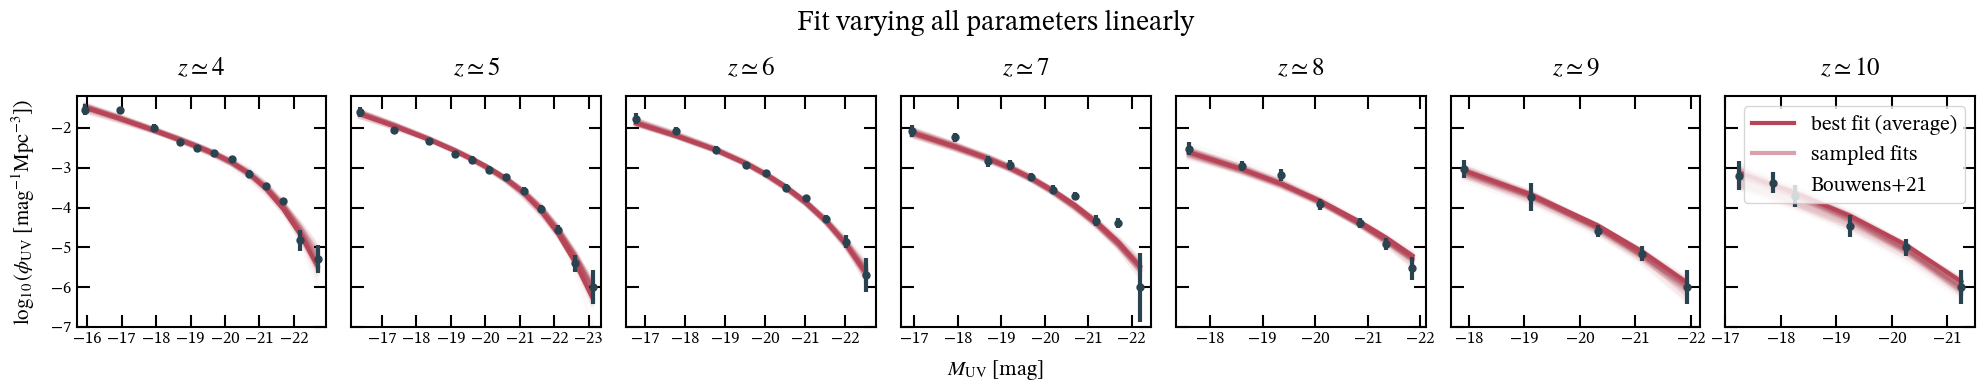

In [36]:
comp_fig = MCMC_vs_data_varyz(datHST, samples_hst, CosmoParams, scale, title = r'Fit varying all parameters linearly', nsamples = 100)
#comp_fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/Bouwens_over_time.png', bbox_inches='tight')

In [22]:
# def plot_param_evolution(best_fit, redshifts, labels):      
#     param_values = best_fit[0::2]
#     z_evolution = best_fit[1::2]
#     N = len(param_values)

#     fig, ax = plt.subplots(N, 1)
#     fig.set_size_inches(4, 4*N)

#     for i, (param, deriv, label) in enumerate(zip(param_values, z_evolution, labels[0::2])):
#         ax[i].plot(redshifts, (param + (deriv*redshifts)))
#         ax[i].set_ylabel(label)

#     ax[-1].set_xlabel('redshift')

#     return fig

In [23]:
def calc_best_fit(samples, scale, bf_type = 'average'):
    assert bf_type in ['mode', 'average'], 'Best fit type must be either mode or average'
    
    if bf_type == 'mode':
        best_fit = mode(samples, axis = 0).mode # Mode seems to be a better statistics than average
    else:
        best_fit = np.average(samples, axis = 0)

    # Deal with weird data (unlog, divide by scale)
    best_fit[1::2] = best_fit[1::2] / scale

    return best_fit

In [24]:
best_fit = calc_best_fit(samples_hst, scale)
chi_squared = -2* log_like(best_fit, datHST, CosmoParams, scale)

In [25]:
for label, param in zip(labels, best_fit):
    label = label.strip('$') # Takes the $ out because the Math line adds its own
    display(Math(f"{label} = {param:.2f}"))

display(Math(f'\chi^2 = {chi_squared:.2f}'))

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_85065/23819085.py:5: SyntaxWarning: invalid escape sequence '\c'
  display(Math(f'\chi^2 = {chi_squared:.2f}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [995]:
# ev_fig = plot_param_evolution(best_fit, redshiftsBouw21, labels)
#ev_fig.savefig('/Users/eb35267/Desktop/figures/ongoing/Bouwens_const_sigma_evolution.png', bbox_inches='tight')

In [26]:
jm_epsilon = np.array([3.940719611387257, -0.835644487121554,
4.9321057388160865, -0.8813262539539082,
5.95882286488929, -0.878982150926344,
7.01536375960235, -1.0135562584726614,
7.873220741075462, -1.1280360370537728,
8.901717126073203, -1.1736330772706727,
10.07687528242205, -1.170950067781292]).reshape(-1, 2)

jm_sigma = np.array([4.012793027097318, 0.738633301702222,
5.076793308262749, 0.7520120901135203,
5.992408533370822, 0.7764734825853163,
6.969036656943029, 0.6646867934254148,
7.96956384212561, 0.41658173127613995,
8.946965170632271, 0.4297965065195233,
10.135170280813973, 0.522955985894868
]).reshape(-1, 2)

Text(0.5, 0, 'redshift')

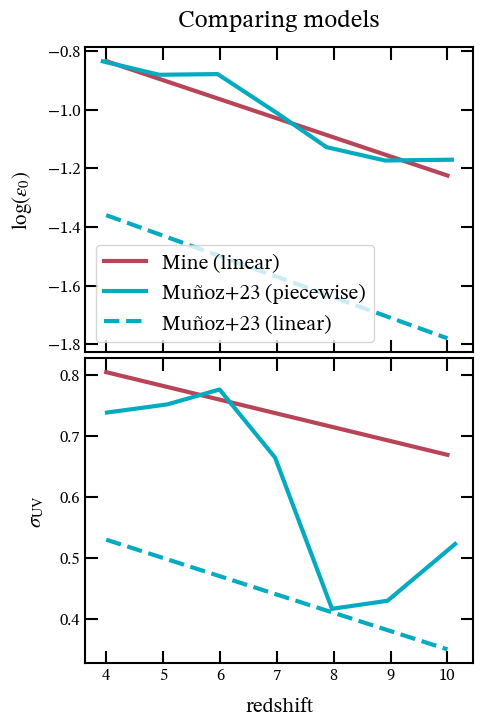

In [27]:
fig, ax = plt.subplots(2, 1, sharex = True)
fig.set_size_inches(5, 8)
plt.subplots_adjust(hspace=0.02)
ax[0].plot(redshiftsBouw21, best_fit[0] + (best_fit[1]*redshiftsBouw21), label = 'Mine (linear)')
ax[0].plot(jm_epsilon[:,0], jm_epsilon[:,1], label = 'Muñoz+23 (piecewise)')
ax[0].plot(redshiftsBouw21,( -1.08 + (-0.07*redshiftsBouw21)), label = 'Muñoz+23 (linear)', color = Plotter.turquoise, linestyle = '--')
ax[0].set_ylabel(labels[0])
ax[0].legend()
ax[0].set_title(r'Comparing models')

ax[1].plot(redshiftsBouw21, best_fit[8] + (best_fit[9]*redshiftsBouw21))
ax[1].plot(jm_sigma[:,0], jm_sigma[:,1])
ax[1].plot(redshiftsBouw21,(.65 + (-0.03*redshiftsBouw21)), color = Plotter.turquoise, linestyle = '--')
ax[1].set_ylabel(labels[8])
ax[1].set_xlabel('redshift')

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/Bouwens_comparison.png', bbox_inches='tight')

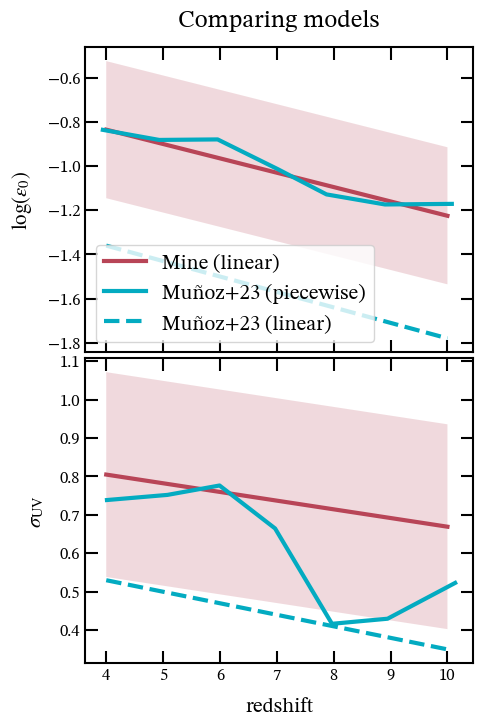

In [31]:
fig, ax = plt.subplots(2, 1, sharex = True)
fig.set_size_inches(5, 8)
plt.subplots_adjust(hspace=0.02)
ax[0].plot(redshiftsBouw21, best_fit[0] + (best_fit[1]*redshiftsBouw21), label = 'Mine (linear)')
sigeps = np.std(samples_hst[:,0])
ax[0].fill_between(redshiftsBouw21,  best_fit[0]-sigeps + (redshiftsBouw21*best_fit[1]), 
                   best_fit[0]+sigeps + (redshiftsBouw21*best_fit[1]), alpha = 0.2)
ax[0].plot(jm_epsilon[:,0], jm_epsilon[:,1], label = 'Muñoz+23 (piecewise)')
ax[0].plot(redshiftsBouw21,( -1.08 + (-0.07*redshiftsBouw21)), label = 'Muñoz+23 (linear)', color = Plotter.turquoise, linestyle = '--')
ax[0].set_ylabel(labels[0])
ax[0].legend()
ax[0].set_title(r'Comparing models')

ax[1].plot(redshiftsBouw21, best_fit[8] + (best_fit[9]*redshiftsBouw21))
sigsig = np.std(samples_hst[:,8])
ax[1].fill_between(redshiftsBouw21,  best_fit[8]-sigsig + (redshiftsBouw21*best_fit[9]), 
                   best_fit[8]+sigsig + (redshiftsBouw21*best_fit[9]), alpha = 0.2)
ax[1].plot(jm_sigma[:,0], jm_sigma[:,1])
ax[1].plot(redshiftsBouw21,(.65 + (-0.03*redshiftsBouw21)), color = Plotter.turquoise, linestyle = '--')
ax[1].set_ylabel(labels[8])
ax[1].set_xlabel('redshift')

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/Bouwens_comparison_errorbars.png', bbox_inches='tight')

# Recursive dust

In [789]:
zcenter = 6
astroparams = param_wrapper(best_fit, CosmoParams, zcenter, scale)

#cannot directly 'dust' the theory since the properties of the IRX-beta relation are calibrated on observed MUV. Recursion instead:
intrinsic_MUV = np.linspace(-30, -10, 10)
currMUV = intrinsic_MUV #currMUV starts as intrinsic MUV
currMUV2 = np.ones_like(currMUV) # comparison starts as 1 (so should be very different)
i = 0
while(np.sum(np.abs((currMUV2-currMUV)/currMUV)) > 0.02):
    currMUV2 = currMUV
    currMUV = intrinsic_MUV + zeus21.UVLFs.AUV(astroparams,zcenter,currMUV) # currMUV is now 
    print('currMUV', currMUV)
    print('currMUV2', currMUV2)
    i += 1
print('i =', i)

currMUV [-25.16922649 -23.83144871 -22.49367094 -21.15589316 -19.81811538
 -18.4398856  -16.54900229 -14.4113459  -12.21070696  -9.99399332]
currMUV2 [-30.         -27.77777778 -25.55555556 -23.33333333 -21.11111111
 -18.88888889 -16.66666667 -14.44444444 -12.22222222 -10.        ]
currMUV [-27.09187435 -25.40208768 -23.71230102 -22.02251435 -20.33272768
 -18.54716023 -16.5569227  -14.41192939 -12.21075911  -9.99400028]
currMUV2 [-25.16922649 -23.83144871 -22.49367094 -21.15589316 -19.81811538
 -18.4398856  -16.54900229 -14.4113459  -12.21070696  -9.99399332]
currMUV [-26.3266605  -24.77697337 -23.22728624 -21.67759911 -20.12791199
 -18.52415401 -16.55640734 -14.41191921 -12.21075888  -9.99400027]
currMUV2 [-27.09187435 -25.40208768 -23.71230102 -22.02251435 -20.33272768
 -18.54716023 -16.5569227  -14.41192939 -12.21075911  -9.99400028]
currMUV [-26.63121561 -25.02576887 -23.42032212 -21.81487538 -20.20942863
 -18.52921649 -16.55644094 -14.41191938 -12.21075888  -9.99400027]
currMUV2 [